# Week 4 — Hidden Markov Models

**Syllabus topics:** Sequential data and Markov models · maximum likelihood for the HMM · the forward and backward algorithms, the sum-product algorithm and scaling factors · the Viterbi algorithm · linear dynamical systems.

Every question below is self-contained: run any cell on its own. All questions use the Seattle daily weather data (`website/data/seattle_weather.csv`); models are trained on 2012–2014 and tested on 2015.

In [1]:
%config InlineBackend.figure_format = "svg"
import sys
sys.path.insert(0, "website")          # weather.py and the data live in website/
from weather import use_style
use_style()

## Theory — Sequential data: Markov models

Weather comes in sequences. A Markov chain says tomorrow depends only on today. Each day is one of three symbols: dry, light rain (up to 5 mm) or heavy rain. We count the transitions, then look several days ahead and at the long-run behaviour.

                  tomorrow dry  tomorrow light rain  tomorrow heavy rain
today dry                 0.76                 0.18                 0.07
today light rain          0.39                 0.34                 0.27
today heavy rain          0.24                 0.34                 0.41 

Three days ahead, P(day + 3 | today) = P³:
             dry  light rain  heavy rain
dry         0.61        0.23        0.16
light rain  0.54        0.26        0.20
heavy rain  0.50        0.27        0.23 

long-run probabilities from the chain: [0.573, 0.247, 0.18] | share of days in the data: [0.574, 0.246, 0.18]
average run of the same symbol (days): {'dry': 4.1, 'light rain': 1.5, 'heavy rain': 1.7}


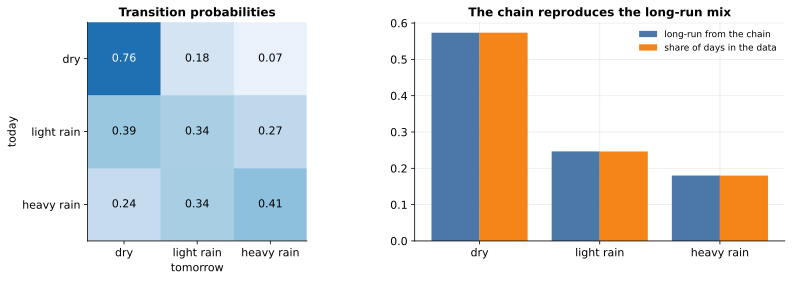

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from weather import load

d = load()
obs = np.digitize(d.precipitation, [0.001, 5.0])                  # 0 = dry, 1 = light rain, 2 = heavy rain
names = ["dry", "light rain", "heavy rain"]

counts = np.zeros((3, 3))
for today, tomorrow in zip(obs[:-1], obs[1:]):
    counts[today, tomorrow] += 1
P = counts / counts.sum(1, keepdims=True)                          # P[i, j] = P(tomorrow = j | today = i)
print(pd.DataFrame(P, index="today " + pd.Index(names), columns="tomorrow " + pd.Index(names)).round(2), "\n")

print("Three days ahead, P(day + 3 | today) = P³:"); print(pd.DataFrame(np.linalg.matrix_power(P, 3), index=names, columns=names).round(2), "\n")
values, vectors = np.linalg.eig(P.T)
stationary = np.real(vectors[:, values.argmax()]); stationary /= stationary.sum()   # long-run share of each symbol: pi = pi P
share = np.bincount(obs, minlength=3) / len(obs)
print("long-run probabilities from the chain:", stationary.round(3).tolist(), "| share of days in the data:", share.round(3).tolist())
print("average run of the same symbol (days):", dict(zip(names, (1 / (1 - np.diag(P))).round(1).tolist())))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
im = ax[0].imshow(P, cmap="Blues", vmin=0, vmax=1); ax[0].grid(False)
ax[0].set_xticks(range(3), names); ax[0].set_yticks(range(3), names); ax[0].set_xlabel("tomorrow"); ax[0].set_ylabel("today"); ax[0].set_title("Transition probabilities")
for i in range(3):
    for j in range(3): ax[0].text(j, i, f"{P[i, j]:.2f}", ha="center", va="center", color="white" if P[i, j] > .5 else "black")
x = np.arange(3); ax[1].bar(x - .2, stationary, .4, label="long-run from the chain"); ax[1].bar(x + .2, share, .4, label="share of days in the data")
ax[1].set_xticks(x, names); ax[1].set_title("The chain reproduces the long-run mix"); ax[1].legend(fontsize=9)
plt.show()

## Theory — The forward and backward algorithms, the sum-product algorithm and scaling factors

An HMM has hidden states (a wet spell or a dry spell) that we never see, only the daily symbols. The forward pass gives "which state are we in now?"; the backward pass adds what later days say. Both are the sum-product algorithm on a chain. Scaling stops the numbers underflowing.

6 days:  brute force log P = -6.902517 | forward algorithm = -6.902517
1461 days: unscaled probability = 0.0 (underflow) | scaled log-likelihood = -1250.5


posterior probabilities add up to 1 on every day: True


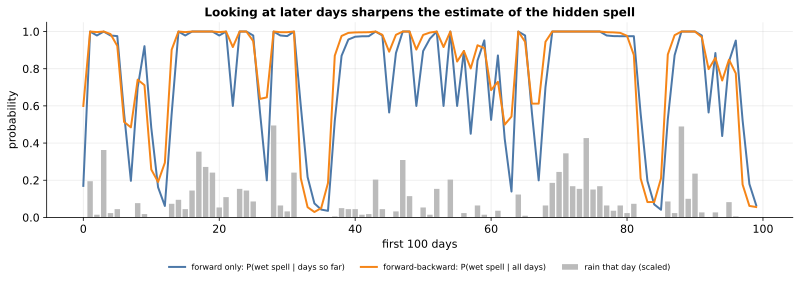

In [3]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from weather import load

d = load()
obs = np.digitize(d.precipitation, [0.001, 5.0])                      # 0 = dry, 1 = light rain, 2 = heavy rain
A = np.array([[.88, .12], [.12, .88]])                                # state 0 = wet spell, state 1 = dry spell (set by hand here)
B = np.array([[.19, .44, .37], [.93, .07, .00]])                      # chance of each symbol in each state
pi = np.array([.5, .5])

def forward_scaled(obs, A, B, pi):
    alpha, c = np.zeros((len(obs), len(pi))), np.zeros(len(obs))
    for t in range(len(obs)):
        alpha[t] = (pi if t == 0 else alpha[t - 1] @ A) * B[:, obs[t]]
        c[t] = alpha[t].sum(); alpha[t] /= c[t]                       # scaling factor c[t]
    return alpha, c

def backward_scaled(obs, A, B, c):
    beta = np.ones((len(obs), len(A)))
    for t in range(len(obs) - 2, -1, -1):
        beta[t] = A @ (B[:, obs[t + 1]] * beta[t + 1]) / c[t + 1]
    return beta

# 1) Check against brute force: add up every possible hidden path of a 6-day sequence
short = obs[:6]
brute = sum(pi[z[0]] * B[z[0], short[0]] * np.prod([A[z[i - 1], z[i]] * B[z[i], short[i]] for i in range(1, 6)]) for z in itertools.product(range(2), repeat=6))
print("6 days:  brute force log P =", round(np.log(brute), 6), "| forward algorithm =", round(np.log(forward_scaled(short, A, B, pi)[1]).sum(), 6))

# 2) Why scaling matters: on all 1,461 days the plain product of probabilities underflows to 0
raw = pi * B[:, obs[0]]
for t in range(1, len(obs)): raw = (raw @ A) * B[:, obs[t]]
alpha, c = forward_scaled(obs, A, B, pi)
print("1461 days: unscaled probability =", raw.sum(), "(underflow) | scaled log-likelihood =", round(float(np.log(c).sum()), 1))

# 3) Forward only (filtering) versus forward-backward (smoothing)
beta = backward_scaled(obs, A, B, c)
gamma = alpha * beta; gamma /= gamma.sum(1, keepdims=True)
print("posterior probabilities add up to 1 on every day:", np.allclose(gamma.sum(1), 1))
days = slice(0, 100)
fig, ax = plt.subplots(figsize=(11, 3.8))
ax.bar(range(100), d.precipitation.values[days] / 56, color="#bbb", label="rain that day (scaled)")
ax.plot(alpha[days, 0], label="forward only: P(wet spell | days so far)"); ax.plot(gamma[days, 0], label="forward-backward: P(wet spell | all days)")
ax.set_xlabel("first 100 days"); ax.set_ylabel("probability"); ax.set_title("Looking at later days sharpens the estimate of the hidden spell"); ax.legend(ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(.5, -.2)); plt.show()

## Theory — The Viterbi algorithm

Forward-backward gives the probability of each state on each day. Viterbi (max-product) gives the single most probable sequence of states. We check it against brute force, then decode the whole of 2012.

brute force best path of the first 8 days: [0, 0, 0, 0, 0, 0, 1, 1]
Viterbi path:                              [0, 0, 0, 0, 0, 0, 1, 1] | identical: True


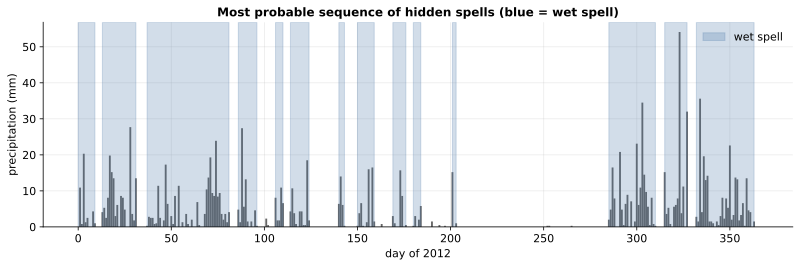

In [4]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from weather import load

d = load()
obs = np.digitize(d.precipitation, [0.001, 5.0])
A = np.array([[.88, .12], [.12, .88]]); B = np.array([[.19, .44, .37], [.93, .07, .00]]); pi = np.array([.5, .5])   # state 0 = wet, 1 = dry

def viterbi(obs, A, B, pi):
    with np.errstate(divide="ignore"):                                 # log(0) = -inf is fine: that path is impossible
        lA, lB, lpi = np.log(A), np.log(B), np.log(pi)
    delta, back = lpi + lB[:, obs[0]], []
    for o in obs[1:]:
        scores = delta[:, None] + lA                                   # best score of arriving in each state from each state
        back.append(scores.argmax(0)); delta = scores.max(0) + lB[:, o]
    path = [int(delta.argmax())]
    for b in back[::-1]: path.append(int(b[path[-1]]))
    return np.array(path[::-1])

short = obs[:8]
def score(z):                                                          # log-probability of a whole path with the observed symbols
    p = pi[z[0]] * B[z[0], short[0]] * np.prod([A[z[i - 1], z[i]] * B[z[i], short[i]] for i in range(1, 8)])
    return np.log(p) if p > 0 else -np.inf
best = max(itertools.product(range(2), repeat=8), key=score)
print("brute force best path of the first 8 days:", list(best))
print("Viterbi path:                             ", viterbi(short, A, B, pi).tolist(), "| identical:", list(best) == viterbi(short, A, B, pi).tolist())

path = viterbi(obs[:366], A, B, pi)
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(range(366), d.precipitation.values[:366], color="#666", width=1)
ax.fill_between(range(366), 0, 1, where=path == 0, color="#4c78a8", alpha=.25, transform=ax.get_xaxis_transform(), label="wet spell")
ax.set_xlabel("day of 2012"); ax.set_ylabel("precipitation (mm)"); ax.set_title("Most probable sequence of hidden spells (blue = wet spell)"); ax.legend(); plt.show()

## Practice 1 — Implement HMM to predict the sequential data

Learn the HMM from the data alone with Baum-Welch (maximum likelihood by EM, using the scaled forward and backward passes), choose the number of hidden states with BIC, decode with Viterbi, and predict whether it rains tomorrow. Train on 2012-2014, test on 2015.

               log-likelihood     BIC
hidden states                        
1                     -1077.1  2168.2
2                      -938.9  1926.7
3                      -924.7  1947.4

BIC chooses 2 hidden states.
transition matrix (rows = from):
[[0.88 0.12]
 [0.12 0.88]]
chance of dry / light / heavy rain in each state (first row = the wet spell):
[[0.19 0.44 0.37]
 [0.93 0.07 0.  ]]
average length of a spell (days): [8.2, 8.6]

rain tomorrow, accuracy on 2015: HMM 0.687 | 'tomorrow = today' 0.703


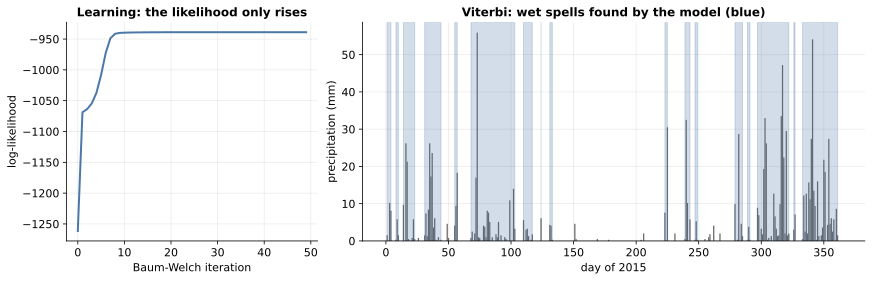

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from weather import load

d = load()
obs = np.digitize(d.precipitation, [0.001, 5.0])                      # 0 = dry, 1 = light rain, 2 = heavy rain
n_train = int((d.date < "2015-01-01").sum())

def forward(obs, A, B, pi):
    alpha, c = np.zeros((len(obs), len(pi))), np.zeros(len(obs))
    for t in range(len(obs)):
        alpha[t] = (pi if t == 0 else alpha[t - 1] @ A) * B[:, obs[t]]
        c[t] = alpha[t].sum(); alpha[t] /= c[t]
    return alpha, c

def baum_welch(obs, K, seed, iters=50):
    rng = np.random.default_rng(seed)
    A, B, pi = rng.dirichlet(np.ones(K) * 5, K), rng.dirichlet(np.ones(3) * 5, K), np.full(K, 1 / K)
    history = []
    for _ in range(iters):
        alpha, c = forward(obs, A, B, pi); history.append(np.log(c).sum())
        beta = np.ones_like(alpha)
        for t in range(len(obs) - 2, -1, -1):
            beta[t] = A @ (B[:, obs[t + 1]] * beta[t + 1]) / c[t + 1]
        gamma = alpha * beta; gamma /= gamma.sum(1, keepdims=True)    # P(state on day t | all days)
        xi = alpha[:-1, :, None] * A[None] * (B[:, obs[1:]].T * beta[1:])[:, None, :]
        xi /= xi.sum((1, 2), keepdims=True)                           # P(state t, state t+1 | all days)
        A = xi.sum(0) / gamma[:-1].sum(0)[:, None]                    # M-step
        B = np.array([[gamma[obs == m, k].sum() for m in range(3)] for k in range(K)]) / gamma.sum(0)[:, None]
        pi = gamma[0]
    return (A, B, pi), history

def viterbi(obs, A, B, pi):
    with np.errstate(divide="ignore"):
        lA, lB, lpi = np.log(A), np.log(B), np.log(pi)
    delta, back = lpi + lB[:, obs[0]], []
    for o in obs[1:]:
        s = delta[:, None] + lA; back.append(s.argmax(0)); delta = s.max(0) + lB[:, o]
    path = [int(delta.argmax())]
    for b in back[::-1]: path.append(int(b[path[-1]]))
    return np.array(path[::-1])

rows, fits = [], {}
for K in [1, 2, 3]:
    runs = [baum_welch(obs[:n_train], K, seed) for seed in range(2)]       # EM can get stuck, so try 2 starts
    fits[K] = max(runs, key=lambda r: r[1][-1])
    ll = fits[K][1][-1]
    rows.append({"hidden states": K, "log-likelihood": round(float(ll), 1), "BIC": round(float(-2 * ll + (K * (K - 1) + 2 * K + K - 1) * np.log(n_train)), 1)})
table = pd.DataFrame(rows).set_index("hidden states"); print(table)
K = int(table.BIC.idxmin()); (A, B, pi), history = fits[K]
order = np.argsort(B[:, 0]); A, B, pi = A[np.ix_(order, order)], B[order], pi[order]   # list the wettest state first
wet = 0
print(f"\nBIC chooses {K} hidden states.\ntransition matrix (rows = from):\n{A.round(2)}\nchance of dry / light / heavy rain in each state (first row = the wet spell):\n{B.round(2)}")
print("average length of a spell (days):", (1 / (1 - np.diag(A))).round(1).tolist())

alpha, c = forward(obs, A, B, pi)                                      # one pass over all days with the learned model
t_days = np.arange(n_train, len(obs) - 1)                              # every 2015 day that has a "tomorrow"
truth = (obs[t_days + 1] > 0).astype(int)
p_rain = (alpha[t_days] @ A @ B)[:, 1:].sum(1)                         # filtered state today -> state tomorrow -> P(rain)
print(f"\nrain tomorrow, accuracy on 2015: HMM {np.mean((p_rain > .5) == truth):.3f} | 'tomorrow = today' {np.mean((obs[t_days] > 0) == truth):.3f}")

path = viterbi(obs, A, B, pi)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8), gridspec_kw={"width_ratios": [1, 2]})
ax[0].plot(history); ax[0].set_xlabel("Baum-Welch iteration"); ax[0].set_ylabel("log-likelihood"); ax[0].set_title("Learning: the likelihood only rises")
days = np.arange(n_train, len(obs))
ax[1].bar(range(len(days)), d.precipitation.values[days], color="#666", width=1)
ax[1].fill_between(range(len(days)), 0, 1, where=path[days] == wet, color="#4c78a8", alpha=.25, transform=ax[1].get_xaxis_transform())
ax[1].set_xlabel("day of 2015"); ax[1].set_ylabel("precipitation (mm)"); ax[1].set_title("Viterbi: wet spells found by the model (blue)")
plt.show()

## Theory — Linear dynamical systems (the Kalman filter)

A linear dynamical system has a hidden state that drifts and a noisy measurement. Here the hidden state is the true temperature level. The Kalman filter tracks it day by day; the smoother also uses later days. We hide 12 days to see how each fills the gap.

error on the 12 hidden days:  Kalman filter 5.21 °C | Kalman smoother 3.75 °C | straight line 4.04 °C


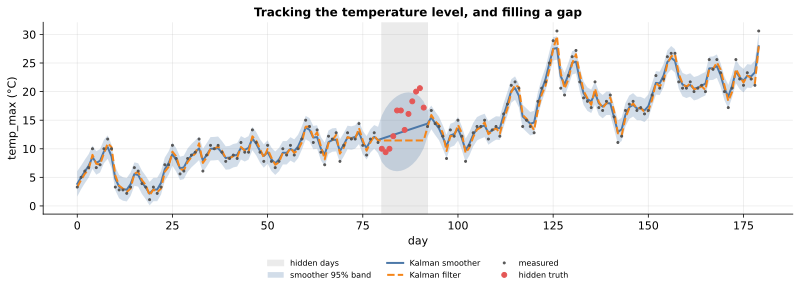

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from weather import load

d = load()
y = d.temp_max.values[365:545].astype(float)                           # 180 days of temp_max (the second half of 2012 and the start of 2013)
gap = slice(80, 92); truth = y[gap].copy()
y_seen = y.copy(); y_seen[gap] = np.nan                                # pretend these 12 days were never recorded

r = 2.0                                                                # measurement noise variance
q = max(np.var(np.diff(y)) - 2 * r, 0.1)                               # how much the true level drifts per day (moment estimate)
n = len(y)
m, P = np.zeros(n), np.zeros(n)                                        # filtered mean and variance
m_pred, P_pred = np.zeros(n), np.zeros(n)
mean, var = y[0], 10.0
for t in range(n):
    m_pred[t], P_pred[t] = mean, var + q                               # predict: the level drifts, uncertainty grows
    if np.isnan(y_seen[t]): mean, var = m_pred[t], P_pred[t]           # no measurement: keep the prediction
    else:
        gain = P_pred[t] / (P_pred[t] + r)                             # Kalman gain: how much to trust the new measurement
        mean, var = m_pred[t] + gain * (y_seen[t] - m_pred[t]), (1 - gain) * P_pred[t]
    m[t], P[t] = mean, var

ms, Ps = m.copy(), P.copy()                                            # Rauch-Tung-Striebel smoother: go backwards
for t in range(n - 2, -1, -1):
    J = P[t] / P_pred[t + 1]
    ms[t] = m[t] + J * (ms[t + 1] - m_pred[t + 1]); Ps[t] = P[t] + J ** 2 * (Ps[t + 1] - P_pred[t + 1])

line = np.interp(np.arange(n), np.where(~np.isnan(y_seen))[0], y_seen[~np.isnan(y_seen)])   # straight-line interpolation
rmse = lambda est: np.sqrt(np.mean((est[gap] - truth) ** 2))
print(f"error on the 12 hidden days:  Kalman filter {rmse(m):.2f} °C | Kalman smoother {rmse(ms):.2f} °C | straight line {rmse(line):.2f} °C")

x = np.arange(n)
fig, ax = plt.subplots(figsize=(11, 3.9))
ax.axvspan(80, 92, color="#999", alpha=.2, label="hidden days")
ax.fill_between(x, ms - 1.96 * np.sqrt(Ps), ms + 1.96 * np.sqrt(Ps), alpha=.25, label="smoother 95% band")
ax.plot(x, ms, label="Kalman smoother"); ax.plot(x, m, "--", label="Kalman filter")
ax.plot(x[~np.isnan(y_seen)], y_seen[~np.isnan(y_seen)], ".", ms=4, color="#555", label="measured"); ax.plot(np.arange(80, 92), truth, "o", ms=5, color="#e45756", label="hidden truth")
ax.set_xlabel("day"); ax.set_ylabel("temp_max (°C)"); ax.set_title("Tracking the temperature level, and filling a gap"); ax.legend(ncol=3, fontsize=8, loc="upper center", bbox_to_anchor=(.5, -.2)); plt.show()